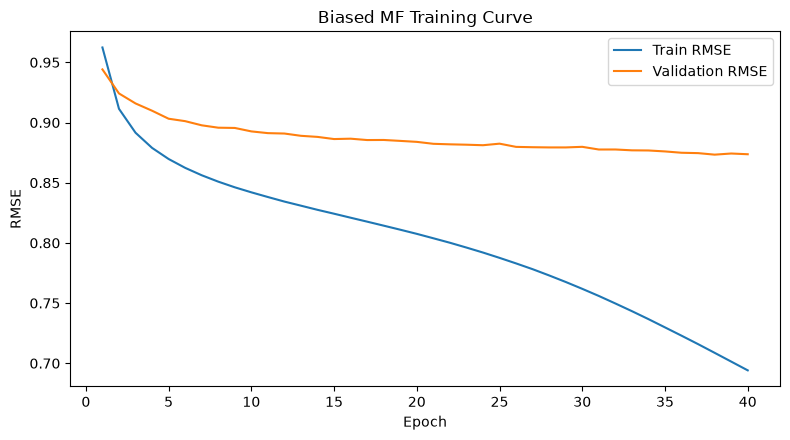

Default best epoch: 38; minimum validation RMSE: 0.8733.


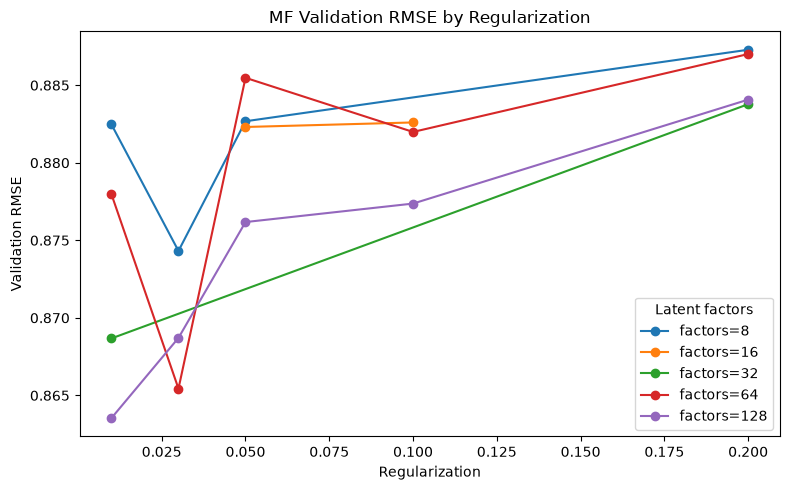

Assertion passed: MF RMSE beats bias
Assertion passed: MF RMSE within 0.01 of best kNN
ASSERTION FAILED: MF NDCG beats count popularity: MF=0.0237; popularity=0.0638


### Assertion notes
- MF NDCG beats count popularity: MF=0.0237; popularity=0.0638

Highest-variance factors: extreme movie titles


,factor,side,title,factor_value,train_ratings
0,100,lowest,Batman Forever (1995),-0.306289,125
1,100,lowest,Pretty Woman (1990),-0.275524,102
2,100,lowest,GoldenEye (1995),-0.237783,114
3,100,lowest,Dogma (1999),-0.222770,58
4,100,lowest,Happy Gilmore (1996),-0.203616,72
5,100,lowest,Top Gun (1986),-0.187258,60
6,100,lowest,Casino Royale (2006),-0.186111,61
7,100,lowest,Star Wars: Episode I - The Phantom Menace (1999),-0.177500,107
8,100,lowest,Casino (1995),-0.176729,61
9,100,lowest,Harry Potter and the Chamber of Secrets (2002),-0.175614,80


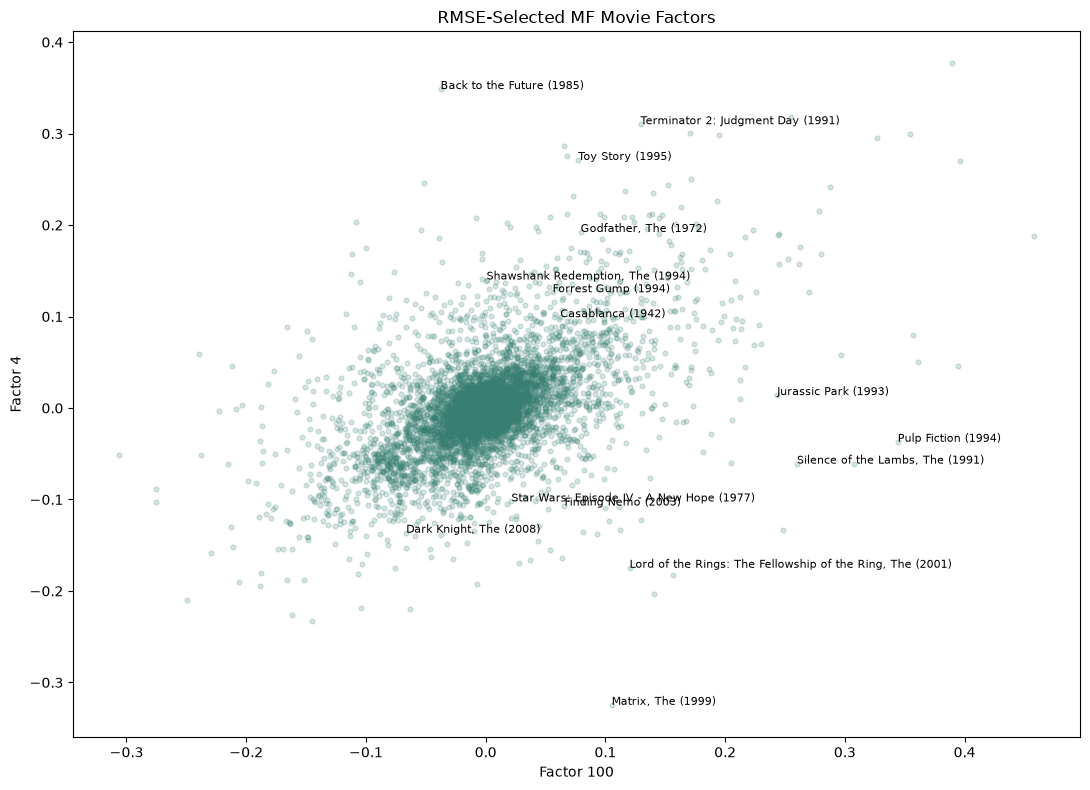

Well-known movies labelled: 15
 seed  val_rmse  ndcg@10  best_epoch
   11  0.864272 0.019594          26
   21  0.863167 0.017881          25
   31  0.865671 0.017149          24
   41  0.865034 0.018455          25
   51  0.865949 0.021391          25
Seed RMSE mean +/- std: 0.8648 +/- 0.0011; NDCG@10 mean +/- std: 0.0189 +/- 0.0017.
Selected configs: {"mf_ndcg": {"best_epoch": 15, "epochs": 60, "init_std": 0.05, "lr": 0.01, "n_factors": 64, "patience": 4, "reg": 0.01, "seed": 42}, "mf_rmse": {"best_epoch": 25, "epochs": 60, "init_std": 0.01, "lr": 0.01, "n_factors": 128, "patience": 4, "reg": 0.01, "seed": 42}}
Search failures: 0 of 25


metric,coverage,mae,map@10,ndcg@10,novelty,precision@10,recall@10,rmse,users_evaluated
model,,,,,,,,,
bias,0.0052,0.6823,0.0196,0.0371,9.1801,0.0222,0.0405,0.8876,554.0
content,0.0488,NaN,0.0383,0.0653,9.0832,0.0316,0.0765,NaN,554.0
item_knn,0.0840,0.6588,0.0404,0.0749,9.8657,0.0419,0.0823,0.8640,554.0
item_knn_implicit,0.0507,NaN,0.0507,0.0903,9.3758,0.0478,0.0964,NaN,554.0
mf,0.0228,0.6626,0.0100,0.0217,11.7599,0.0146,0.0194,0.8635,554.0
mf_ndcg,0.0231,0.6732,0.0110,0.0237,11.0781,0.0161,0.0220,0.8780,554.0
popularity_bayes,0.0053,0.7601,0.0214,0.0404,9.0163,0.0245,0.0446,0.9829,554.0
popularity_count,0.0089,0.8187,0.0374,0.0638,8.4866,0.0327,0.0768,1.0415,554.0
random,0.4320,0.8187,0.0001,0.0004,19.8228,0.0005,0.0003,1.0415,554.0


In [4]:
import sys; sys.path.append("..")

import itertools
import json
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import ARTIFACTS, DATA_PROC, REL_THRESHOLD, REPORTS, TOP_K
from src.evaluate import evaluate_ranking, evaluate_rating
from src.models.mf import BiasedMF

train = pd.read_parquet(DATA_PROC / "train.parquet")
val = pd.read_parquet(DATA_PROC / "val.parquet")
movies = pd.read_parquet(DATA_PROC / "movies.parquet")
n_users = 610
n_items = len(movies)
assert np.array_equal(movies["i"].to_numpy(), np.arange(n_items))

class CachedMFScores:
    def __init__(self, model):
        self.scores = (model.Q @ model.P.T).T + model.bi[None, :]

    def score_user(self, user):
        return self.scores[int(user)]


def evaluate_mf(model):
    rating = evaluate_rating(model, val)
    ranking = evaluate_ranking(CachedMFScores(model), train, val, n_items, k=TOP_K, thr=REL_THRESHOLD)
    return rating, ranking


# Default validation fit and training curve.
default_model = BiasedMF(verbose=False).fit(train, n_users, n_items, val=val)
default_history = pd.DataFrame(default_model.history)
REPORTS.mkdir(parents=True, exist_ok=True)
plot_dir = REPORTS / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(default_history.epoch, default_history.train_rmse, label="Train RMSE")
ax.plot(default_history.epoch, default_history.val_rmse, label="Validation RMSE")
ax.set(title="Biased MF Training Curve", xlabel="Epoch", ylabel="RMSE")
ax.legend()
fig.tight_layout()
fig.savefig(plot_dir / "mf_training_curve.png", dpi=160)
plt.show()
print(f"Default best epoch: {default_model.best_epoch}; minimum validation RMSE: {default_history.val_rmse.min():.4f}.")

# Seeded random search of 25 distinct configurations.
parameter_grid = list(itertools.product([8, 16, 32, 64, 128], [0.01, 0.03, 0.05, 0.1, 0.2], [0.002, 0.005, 0.01], [0.01, 0.05, 0.1]))
search_rng = np.random.default_rng(2026)
trial_indices = search_rng.choice(len(parameter_grid), size=25, replace=False)
search_rows = []
for trial, index in enumerate(trial_indices, start=1):
    n_factors, reg, lr, init_std = parameter_grid[index]
    params = {"n_factors": int(n_factors), "reg": float(reg), "lr": float(lr), "init_std": float(init_std), "epochs": 60, "seed": 42, "patience": 4}
    try:
        model = BiasedMF(**params, verbose=False).fit(train, n_users, n_items, val=val)
        rating, ranking = evaluate_mf(model)
        search_rows.append({"trial": trial, **params, "best_epoch": model.best_epoch, "val_rmse": rating["rmse"], "val_mae": rating["mae"], "ndcg@10": ranking["ndcg@10"], "recall@10": ranking["recall@10"], "coverage": ranking["coverage"], "novelty": ranking["novelty"], "users_evaluated": ranking["users_evaluated"], "status": "ok", "failure": "", "params": json.dumps(params, sort_keys=True)})
    except (ValueError, FloatingPointError, OverflowError) as error:
        search_rows.append({"trial": trial, **params, "best_epoch": np.nan, "val_rmse": np.nan, "val_mae": np.nan, "ndcg@10": np.nan, "recall@10": np.nan, "coverage": np.nan, "novelty": np.nan, "users_evaluated": 0, "status": "failed", "failure": str(error), "params": json.dumps(params, sort_keys=True)})

search_results = pd.DataFrame(search_rows)
search_results.to_csv(REPORTS / "mf_search.csv", index=False)
successful = search_results.loc[search_results.status == "ok"].copy()
if successful.empty:
    raise RuntimeError("All matrix-factorization search trials failed")
rmse_winner = successful.loc[successful.val_rmse.idxmin()]
ndcg_winner = successful.loc[successful["ndcg@10"].idxmax()]


def config_from_row(row):
    return {"n_factors": int(row.n_factors), "reg": float(row.reg), "lr": float(row.lr), "init_std": float(row.init_std), "epochs": 60, "seed": 42, "patience": 4, "best_epoch": int(row.best_epoch)}


mf_rmse_config = config_from_row(rmse_winner)
mf_ndcg_config = config_from_row(ndcg_winner)
reg_summary = successful.groupby(["n_factors", "reg"], as_index=False).val_rmse.median()
fig, ax = plt.subplots(figsize=(8, 5))
for n_factors, group in reg_summary.groupby("n_factors"):
    group = group.sort_values("reg")
    ax.plot(group.reg, group.val_rmse, marker="o", label=f"factors={n_factors}")
ax.set(title="MF Validation RMSE by Regularization", xlabel="Regularization", ylabel="Validation RMSE")
ax.legend(title="Latent factors")
fig.tight_layout()
fig.savefig(plot_dir / "mf_rmse_vs_reg.png", dpi=160)
plt.show()


def fit_final(config):
    keys = ("n_factors", "lr", "reg", "epochs", "init_std", "seed", "patience")
    return BiasedMF(**{key: config[key] for key in keys}, verbose=False).fit(train, n_users, n_items, val=val)


mf_rmse_model = fit_final(mf_rmse_config)
mf_ndcg_model = fit_final(mf_ndcg_config)
mf_rmse_config["best_epoch"] = mf_rmse_model.best_epoch
mf_ndcg_config["best_epoch"] = mf_ndcg_model.best_epoch
ARTIFACTS.mkdir(parents=True, exist_ok=True)
with (ARTIFACTS / "mf_config.json").open("w", encoding="utf-8") as file:
    json.dump({"mf_rmse": mf_rmse_config, "mf_ndcg": mf_ndcg_config}, file, indent=2, sort_keys=True)
joblib.dump(mf_rmse_model, ARTIFACTS / "mf.joblib")
joblib.dump(mf_ndcg_model, ARTIFACTS / "mf_ndcg.joblib")
mf_rmse_rating, mf_rmse_ranking = evaluate_mf(mf_rmse_model)
mf_ndcg_rating, mf_ndcg_ranking = evaluate_mf(mf_ndcg_model)

# Replace old MF results on rerun, preserving the established schema.
results_path = REPORTS / "results_val.csv"
previous_results = pd.read_csv(results_path)
results_val = previous_results.loc[~previous_results.model.isin(["mf", "mf_ndcg"])].copy()
ranking_names = ["precision@10", "recall@10", "ndcg@10", "map@10", "coverage", "novelty", "users_evaluated"]
for name, config, rating, ranking in (("mf", mf_rmse_config, mf_rmse_rating, mf_rmse_ranking), ("mf_ndcg", mf_ndcg_config, mf_ndcg_rating, mf_ndcg_ranking)):
    params = json.dumps(config, sort_keys=True)
    rows = [{"model": name, "split": "val", "metric": metric, "value": rating[metric], "params": params} for metric in ("rmse", "mae")]
    rows.extend({"model": name, "split": "val", "metric": metric, "value": ranking[metric], "params": params} for metric in ranking_names)
    results_val = pd.concat([results_val, pd.DataFrame(rows)], ignore_index=True)
results_val = results_val[["model", "split", "metric", "value", "params"]]
results_val.to_csv(results_path, index=False)


def previous_value(model_name, metric):
    values = previous_results.loc[(previous_results.model == model_name) & (previous_results.metric == metric), "value"]
    return float(values.iloc[-1])


bias_rmse = previous_value("bias", "rmse")
item_knn_rmse = previous_value("item_knn", "rmse")
user_knn_rmse = previous_value("user_knn", "rmse")
popularity_ndcg = previous_value("popularity_count", "ndcg@10")
assertion_notes = []


def check_assertion(label, condition, detail):
    try:
        assert condition, detail
        print("Assertion passed:", label)
    except AssertionError as error:
        note = f"{label}: {error}"
        assertion_notes.append(note)
        print("ASSERTION FAILED:", note)


check_assertion("MF RMSE beats bias", mf_rmse_rating["rmse"] < bias_rmse, f"MF={mf_rmse_rating['rmse']:.4f}; bias={bias_rmse:.4f}")
check_assertion("MF RMSE within 0.01 of best kNN", mf_rmse_rating["rmse"] <= min(item_knn_rmse, user_knn_rmse) + 0.01, f"MF={mf_rmse_rating['rmse']:.4f}; best kNN={min(item_knn_rmse, user_knn_rmse):.4f}")
check_assertion("MF NDCG beats count popularity", mf_ndcg_ranking["ndcg@10"] > popularity_ndcg, f"MF={mf_ndcg_ranking['ndcg@10']:.4f}; popularity={popularity_ndcg:.4f}")
if assertion_notes:
    display(Markdown("### Assertion notes\n" + "\n".join(f"- {note}" for note in assertion_notes)))

# Latent factor extremes among items with at least 50 train ratings.
item_counts = np.bincount(train.i.to_numpy(dtype=np.int64), minlength=n_items)
eligible = np.flatnonzero(item_counts >= 50)
variances = np.var(mf_rmse_model.Q, axis=0)
factors = np.argsort(variances)[-3:][::-1]
latent_rows = []
for factor in factors:
    order = eligible[np.argsort(mf_rmse_model.Q[eligible, factor])]
    for side, indices in (("lowest", order[:10]), ("highest", order[-10:][::-1])):
        for item in indices:
            latent_rows.append({"factor": int(factor), "side": side, "title": movies.iloc[int(item)].title, "factor_value": float(mf_rmse_model.Q[item, factor]), "train_ratings": int(item_counts[item])})
latent_table = pd.DataFrame(latent_rows)
print("Highest-variance factors: extreme movie titles")
display(latent_table)

known_titles = ["Toy Story (1995)", "The Dark Knight (2008)", "Casablanca (1942)", "Pulp Fiction (1994)", "The Shawshank Redemption (1994)", "Forrest Gump (1994)", "The Matrix (1999)", "Star Wars: Episode IV - A New Hope (1977)", "Jurassic Park (1993)", "The Silence of the Lambs (1991)", "The Godfather (1972)", "The Lord of the Rings: The Fellowship of the Ring (2001)", "Finding Nemo (2003)", "Terminator 2: Judgment Day (1991)", "Back to the Future (1985)"]


def find_movie(query):
    exact = movies.loc[movies.title == query]
    if not exact.empty:
        return exact.iloc[0]
    title_part, year_part = query.rsplit(" (", 1)
    title_part = title_part.removeprefix("The ")
    year_part = year_part.rstrip(")")
    mask = movies.title.str.contains(re.escape(title_part), case=False, regex=True) & movies.title.str.endswith(f"({year_part})")
    matches = movies.loc[mask]
    return None if matches.empty else matches.iloc[0]


labels = [row for title in known_titles if (row := find_movie(title)) is not None]
x_factor, y_factor = factors[:2]
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(mf_rmse_model.Q[:, x_factor], mf_rmse_model.Q[:, y_factor], s=12, alpha=0.2, color="#387f72")
for movie in labels:
    item = int(movie.i)
    ax.annotate(movie.title, (mf_rmse_model.Q[item, x_factor], mf_rmse_model.Q[item, y_factor]), fontsize=8)
ax.set(title="RMSE-Selected MF Movie Factors", xlabel=f"Factor {x_factor}", ylabel=f"Factor {y_factor}")
fig.tight_layout()
fig.savefig(plot_dir / "mf_factors.png", dpi=160)
plt.show()
print("Well-known movies labelled:", len(labels))

# Five-seed stability for the RMSE-selected hyperparameters.
seed_rows = []
for seed in [11, 21, 31, 41, 51]:
    keys = ("n_factors", "lr", "reg", "epochs", "init_std", "patience")
    model = BiasedMF(**{key: mf_rmse_config[key] for key in keys}, seed=seed, verbose=False).fit(train, n_users, n_items, val=val)
    rating, ranking = evaluate_mf(model)
    seed_rows.append({"seed": seed, "val_rmse": rating["rmse"], "ndcg@10": ranking["ndcg@10"], "best_epoch": model.best_epoch})
seed_results = pd.DataFrame(seed_rows)
print(seed_results.to_string(index=False))
print(f"Seed RMSE mean +/- std: {seed_results.val_rmse.mean():.4f} +/- {seed_results.val_rmse.std(ddof=1):.4f}; NDCG@10 mean +/- std: {seed_results['ndcg@10'].mean():.4f} +/- {seed_results['ndcg@10'].std(ddof=1):.4f}.")
print("Selected configs:", json.dumps({"mf_rmse": mf_rmse_config, "mf_ndcg": mf_ndcg_config}, sort_keys=True))
print("Search failures:", int((search_results.status == "failed").sum()), "of", len(search_results))
final_table = results_val.pivot_table(index="model", columns="metric", values="value", aggfunc="first")
display(final_table.round(4))


## Model selection and interpretation

The validation-selected configurations differ: **mf_rmse** uses 128 factors, reg=0.01, lr=0.01, init_std=0.01 (best epoch 25; RMSE 0.8635), while **mf_ndcg** uses 64 factors, reg=0.01, lr=0.01, init_std=0.05 (best epoch 15; NDCG@10 0.0237). Rating-error minimization and top-ranked relevant-item ordering are different objectives, so a lower RMSE does not guarantee better NDCG.

The NDCG assertion did not pass: **mf_ndcg NDCG@10 is 0.0237 versus 0.0638 for count popularity**. This remains reported rather than hidden. The other two assertions pass: mf_rmse RMSE is 0.8635 versus 0.8876 for bias, and it is within 0.01 of the best kNN RMSE (0.8640).

Factor readings are descriptive, not genre labels. **Factor 100** places *Batman Forever* and *Pretty Woman* among its lowest values, while *Alien*, *Blade Runner*, *Pulp Fiction*, and *Groundhog Day* are high; it appears to contrast some franchise/romance titles with sci-fi and offbeat favorites. **Factor 4** has *The Matrix*, *The Matrix Reloaded*, and *The Fellowship of the Ring* low, with *Back to the Future*, *Terminator 2*, and *2001: A Space Odyssey* high, suggesting a different franchise-era/classic-science-fiction axis. **Factor 55** places *The Shawshank Redemption*, *Star Wars*, and *Forrest Gump* low, while *Scream*, *Austin Powers*, and *Dumb & Dumber* are high; this may reflect a loose classic-drama versus genre-comedy contrast. Latent dimensions are learned jointly and should not be treated as clean standalone categories.

Across five seeds for the mf_rmse configuration, validation RMSE is 0.8648 +/- 0.0011 and NDCG@10 is 0.0189 +/- 0.0017.